In [25]:
from langgraph.graph import StateGraph, START, END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import RemoveMessage
import os
from typing import Literal, Optional
from pydantic import BaseModel
from langchain_core.messages import trim_messages

In [26]:
from langchain_core.prompts import ChatPromptTemplate
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [27]:
load_dotenv()

True

In [28]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

In [29]:
chat_model = os.getenv('CHAT_MODEL')
llm = init_chat_model(model=chat_model)
llm.invoke('Hi')

AIMessage(content='Hi! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 7, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFVe8LibRP2O3d9qdKBol7Sus9zix', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02745-b6e2-7d33-a5d0-e3584bce9bb7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 14, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [30]:
class ChatState(BaseModel):
    messages : Annotated[list[AnyMessage],add_messages]
    summary: Optional[str] = None

In [31]:
def add(a:int, b:int) -> int:
    '''
        This is a addition function
        a = int
        b = int 
        
        returns sum of two number
        
    '''
    return a+b

In [32]:
from langchain_community.utilities import SerpAPIWrapper
SERPAPI_API_KEY = os.getenv("SERPAPI_API_KEY")
serpapi = SerpAPIWrapper()
def google_search(query: str, num_results: int = 5):
    """This function can perform a google search using the SerpAPIWrapper and return the top results."""
    raw = serpapi.results(query)
    organic = raw.get("organic_results", [])[:num_results]
    return [
        {
            "title": item.get("title", ""),
            "link": item.get("link", ""),
            "snippet": item.get("snippet", "")
        }
        for item in organic
    ]


In [33]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [34]:
tools = [add,google_search]

In [35]:
llm_with_tool = llm.bind_tools(tools)

In [36]:
response = llm_with_tool.invoke([HumanMessage(content=f"tell me latest news")])

In [37]:
response.dict()

C:\Users\admin\AppData\Local\Temp\ipykernel_18884\3202056457.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  response.dict()


{'content': '',
 'additional_kwargs': {'refusal': None},
 'response_metadata': {'token_usage': {'completion_tokens': 24,
   'prompt_tokens': 192,
   'total_tokens': 216,
   'completion_tokens_details': {'accepted_prediction_tokens': 0,
    'audio_tokens': 0,
    'reasoning_tokens': 0,
    'rejected_prediction_tokens': 0},
   'prompt_tokens_details': {'audio_tokens': 0,
    'cache_write_tokens': None,
    'cached_tokens': 0}},
  'model_provider': 'openai',
  'model_name': 'gpt-5.4-nano-2026-03-17',
  'system_fingerprint': None,
  'id': 'chatcmpl-EFVeM7XPOSPwmfOLqIDaUjFMCSfGC',
  'service_tier': 'default',
  'finish_reason': 'tool_calls',
  'logprobs': None},
 'type': 'ai',
 'name': None,
 'id': 'lc_run--01a02745-ed12-7b52-ae9f-2e9ca1cb2d46-0',
 'tool_calls': [{'name': 'google_search',
   'args': {'query': 'latest news headlines', 'num_results': 5},
   'id': 'call_DSPLglxuaZrDN7kIW6jD9U92',
   'type': 'tool_call'}],
 'invalid_tool_calls': [],
 'usage_metadata': {'input_tokens': 192,
  'o

In [38]:
response.content, response.tool_calls,response.response_metadata.get('finish_reason')

('',
 [{'name': 'google_search',
   'args': {'query': 'latest news headlines', 'num_results': 5},
   'id': 'call_DSPLglxuaZrDN7kIW6jD9U92',
   'type': 'tool_call'}],
 'tool_calls')

In [39]:
from langchain_core.messages import SystemMessage

def chat_bot(state: ChatState):

    trimmed_messages = trim_messages(
        state.messages,
        max_tokens=4000,
        strategy="last",
        token_counter=llm,
        start_on="human",  # ← Forces trimming to start from HumanMessage
    )

    # Add system prompt to guide the LLM
    system_msg = SystemMessage(content="""You are a helpful assistant. 
    When you receive tool results, provide natural, conversational responses. 
    Explain your reasoning clearly and be friendly.""")
    
    # Prepend system message to the conversation
    messages_with_system = [system_msg] + trimmed_messages
    
    response = llm_with_tool.invoke(messages_with_system)
    return {"messages": [response]}

In [40]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
### Entire Chatbot With LangGraph
from IPython.display import Image, display

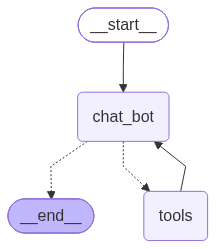

In [41]:
graph = StateGraph(ChatState)


graph.add_node("chat_bot", chat_bot)
graph.add_node('tools',ToolNode(tools))

graph.add_edge(START,'chat_bot')
graph.add_conditional_edges('chat_bot',tools_condition)
graph.add_edge("tools", "chat_bot")  


workflow = graph.compile()

# View
display(Image(workflow.get_graph().draw_mermaid_png()))

In [42]:
response = workflow.invoke({
    "messages": [HumanMessage(content='what is 2+3 and 3+4?')]
})

# Print all messages
for msg in response['messages']:
    print(f"{msg.__class__.__name__}: {msg.content}")
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"  Tool calls: {msg.tool_calls}")
    print()

# Print just the final answer
print("Final Answer:")
print(response['messages'][-1].content)

HumanMessage: what is 2+3 and 3+4?

AIMessage: 
  Tool calls: [{'name': 'add', 'args': {'a': 2, 'b': 3}, 'id': 'call_FkRzUX642UCf6UqOvqFdf4n7', 'type': 'tool_call'}, {'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_KhgZ6sNe6LrlUizc7blanKAX', 'type': 'tool_call'}]

ToolMessage: 5

ToolMessage: 7

AIMessage: 2 + 3 = **5**  
3 + 4 = **7**

Final Answer:
2 + 3 = **5**  
3 + 4 = **7**


In [43]:
# Configuration for message summarization
max_messages = 5

In [44]:
def route_messages(state: ChatState) -> Literal["summarization", "chat_bot"]:
    
    total_message = len(state.messages)

    print(f"Total Messages: {total_message}")

    if total_message > max_messages:
        print('--------------- returned summarization -----------------')
        return "summarization"

    print('--------------- returned chatbot -----------------')
    return "chat_bot"

In [45]:
def summarization(state: ChatState):
    print('------------------ SUMMARIZATION ---------------')
    messages = state.messages
    old_messages = messages[:-max_messages]
    previous_summary = state.summary or ""  

    if not old_messages:
        return {}

    conversation = "\n".join(
        f"{message.type}: {message.content}"
        for message in old_messages
    )

    if previous_summary:
        # Update existing summary with new messages
        summarization_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    "Update the existing summary by incorporating the new conversation messages. "
                    "Preserve all important facts, user preferences, names, decisions, and unfinished tasks "
                    "from both the previous summary and the new messages.",
                ),
                (
                    "human",
                    "Previous summary:\n{previous_summary}\n\n"
                    "New conversation messages to add:\n{conversation}",
                ),
            ]
        )
        prompt_value = summarization_prompt.invoke(
            {
                "previous_summary": previous_summary,
                "conversation": conversation,
            }
        )
    else:
        # Create initial summary
        summarization_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    "Summarize the conversation history concisely. "
                    "Preserve important facts, user preferences, names, "
                    "decisions, and unfinished tasks.",
                ),
                (
                    "human",
                    "Conversation history to summarize:\n\n{conversation}",
                ),
            ]
        )
        prompt_value = summarization_prompt.invoke(
            {"conversation": conversation}
        )

    summary_response = llm.invoke(prompt_value)

    return {
        "messages": [
            RemoveMessage(id=message.id)
            for message in old_messages
        ],
        "summary": summary_response.content,
    }

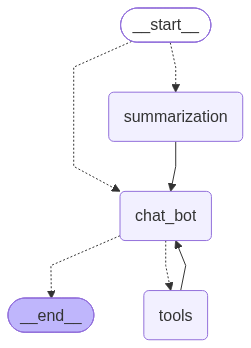

In [46]:
checkpointer = InMemorySaver()
graph = StateGraph(ChatState)


graph.add_node("chat_bot", chat_bot)
graph.add_node("summarization", summarization)
graph.add_node('tools',ToolNode(tools))

graph.add_conditional_edges(
    START,
    route_messages,
    {
        "summarization": "summarization",
        "chat_bot": "chat_bot",
    },
)
graph.add_edge("summarization", "chat_bot")
graph.add_conditional_edges('chat_bot',tools_condition)
graph.add_edge("tools", "chat_bot")  


checkpointer_graph = graph.compile(checkpointer=checkpointer)

# View
display(Image(checkpointer_graph.get_graph().draw_mermaid_png()))

In [47]:
print('To end: exit,q,quit')

_user_id = None 

while True:

    if not _user_id : 
        _user_id = input('User id: ')

    _input = input('User: ')
    
    if _input in ('q','quit','exit'):
        _user_id = None
        break
    
    message = {
        'messages': [HumanMessage(content=_input)]
    }

    config = {
        'configurable':{
            'thread_id':_user_id
        }
    }

    response = checkpointer_graph.invoke(message, config)
    print('User: ', _input)
    print('AI: ', response["messages"][-1].content)

To end: exit,q,quit
Total Messages: 1
--------------- returned chatbot -----------------
User:  what is the latest news around AI and also finance
AI:  Here are a few **recent themes in AI + finance** (based on the latest coverage I’m seeing), with links so you can read the full stories:

### 1) AI investment continues to surge—markets still cautious
- **What’s happening:** Even as some economic uncertainty eases, there’s still “investment anxiety” around how quickly AI capex translates into profits.
- **Source:** Reuters commentary (Aug 18, 2026)  
  https://www.reuters.com/commentary/reuters-open-interest/even-market-clouds-clear-ai-investment-anxiety-still-gnaws-2026-08-18/

### 2) AI is increasingly central to business and finance strategy
- **What’s happening:** Ongoing reporting focuses on how AI is being embedded into corporate operations—including financial services.
- **Source:** Financial Times AI hub (Aug 21, 2026)  
  https://www.ft.com/artificial-intelligence

### 3) Big A